# Decision Tree Classifier 🌳🌳
## Importing libraries and dataset

0. Import usual libraries

In [125]:
# Importing usual libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Machine learning tools
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)




In [126]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Import the bl.txt dataset and display the first few lines.

In [127]:
with open("bl.txt", "r") as f:
    print(f.readline())


balance,left_weight,left_distance,right_weight,right_distance



In [128]:
df = pd.read_csv("/content/drive/MyDrive/JedhaBootcamp/bl.txt")

df.head()

,balance,left_weight,left_distance,right_weight,right_distance
0,B,1,1,1,1
1,R,1,1,1,2
2,R,1,1,1,3
3,R,1,1,1,4
4,R,1,1,1,5


2. Display a descriptive statistic table

In [129]:
df.describe(include='all')


,balance,left_weight,left_distance,right_weight,right_distance
count,625,625.000000,625.000000,625.000000,625.000000
unique,3,NaN,NaN,NaN,NaN
top,R,NaN,NaN,NaN,NaN
freq,288,NaN,NaN,NaN,NaN
mean,NaN,3.000000,3.000000,3.000000,3.000000
std,NaN,1.415346,1.415346,1.415346,1.415346
min,NaN,1.000000,1.000000,1.000000,1.000000
25%,NaN,2.000000,2.000000,2.000000,2.000000
50%,NaN,3.000000,3.000000,3.000000,3.000000
75%,NaN,4.000000,4.000000,4.000000,4.000000


In [130]:
print(df.info())
print("\nMissing values:\n", df.isna().sum())
df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625 entries, 0 to 624
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   balance         625 non-null    object
 1   left_weight     625 non-null    int64 
 2   left_distance   625 non-null    int64 
 3   right_weight    625 non-null    int64 
 4   right_distance  625 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 24.5+ KB
None

Missing values:
 balance           0
left_weight       0
left_distance     0
right_weight      0
right_distance    0
dtype: int64


,balance,left_weight,left_distance,right_weight,right_distance
count,625,625.000000,625.000000,625.000000,625.000000
unique,3,NaN,NaN,NaN,NaN
top,R,NaN,NaN,NaN,NaN
freq,288,NaN,NaN,NaN,NaN
mean,NaN,3.000000,3.000000,3.000000,3.000000
std,NaN,1.415346,1.415346,1.415346,1.415346
min,NaN,1.000000,1.000000,1.000000,1.000000
25%,NaN,2.000000,2.000000,2.000000,2.000000
50%,NaN,3.000000,3.000000,3.000000,3.000000
75%,NaN,4.000000,4.000000,4.000000,4.000000


3. What is the dataset shape?

In [131]:
df.shape

(625, 5)

## Preprocessing

4. Separate the target variable "balance" into a Y object and the explanatory variables into a X object.

In [132]:
X = df.drop(columns=['balance'])
y = df['balance']

print(X.head())


   left_weight  left_distance  right_weight  right_distance
0            1              1             1               1
1            1              1             1               2
2            1              1             1               3
3            1              1             1               4
4            1              1             1               5


In [133]:
print(y.head())

0    B
1    R
2    R
3    R
4    R
Name: balance, dtype: object


5. Split the data between a train set with 70% of the data and use the rest to build a test set with random_state=42

In [134]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

Objectif : L'arbre cherche le meilleur split (meilleure coupure)

## Comparing Decision Trees: Gini or Entropy Criterion?

6. Create an instance of a 'DecisionTreeClassifier' with GINI criterion, and fit it on training data. Beforehand, make any preprocessing that you think is necessary.

indice de Gini = calcule la probabilité que deux échantillons choisis au hasard aient des classes différentes.

Les arbres (decision tree) et forêts(random forest) sont insensibles aux transformations linéaires

In [135]:
clf_gini = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)


In [136]:
clf_gini.fit(X_train, y_train)
print("Model trained successfully!")


Model trained successfully!


7. Display your tree using `plot_tree` from [sklearn.tree](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html)

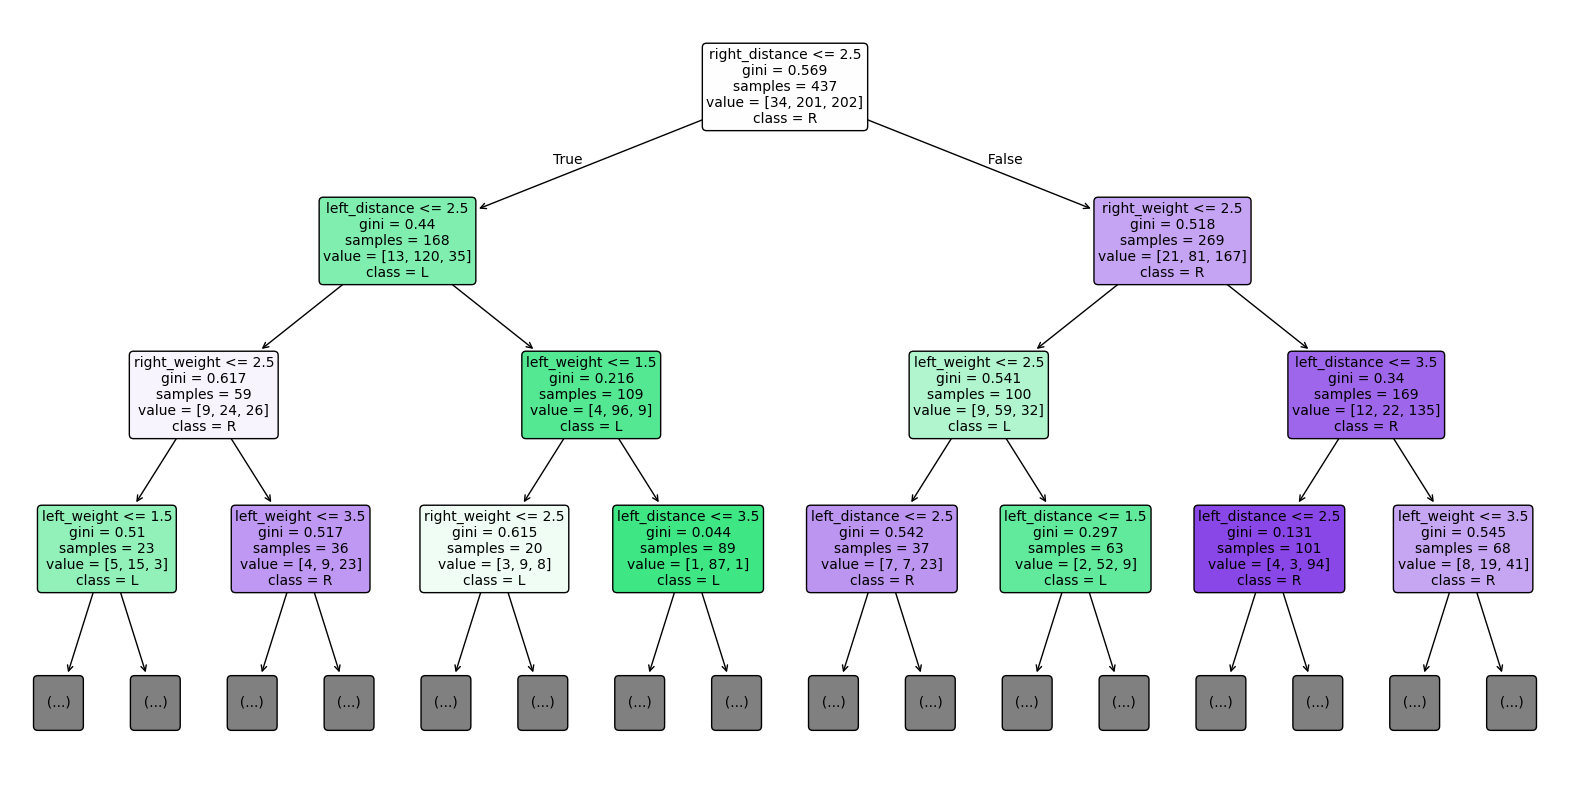

In [137]:
plt.figure(figsize=(20,10))  # taille du graphique
plot_tree(
    clf_gini,
    feature_names=X.columns,
    class_names=clf_gini.classes_, # B, L, R
    max_depth=3, # limite la profondeur visuelle pour les arbres profonds
    filled=True, # couleurs selon les classes
    rounded=True,# arrondis les angles
    fontsize=10
)
plt.show()


8. Create an instance of a DecisionTreeClassifier using the entropy criterion.

Entropie = niveau d’incertitude dans un nœud.

| Critère     | Avantage                               | Inconvénient                   | Tendance                                    |
| ----------- | -------------------------------------- | ------------------------------ | ------------------------------------------- |
| **GINI**    | Plus rapide à calculer                 | Très similaire à Entropy       | Tendance à favoriser la classe majoritaire  |
| **ENTROPY** | Plus théorique, basé sur l'information | Calcul plus lourd (logarithme) | Tendance à créer des splits plus équilibrés |



autre critère d'impureté dans scikit_learn = Log_loss

In [138]:
clf_entropy = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)


In [139]:
clf_entropy.fit(X_train, y_train)
print("Entropy Decision Tree trained successfully!")


Entropy Decision Tree trained successfully!


9. Display the tree

1 2 3 4 5
[L R B L] = target

[4 4 3 3] = features
right_distance inf à 3
right_weight inf à 3
left_weight inf ou égale à 3
 = R

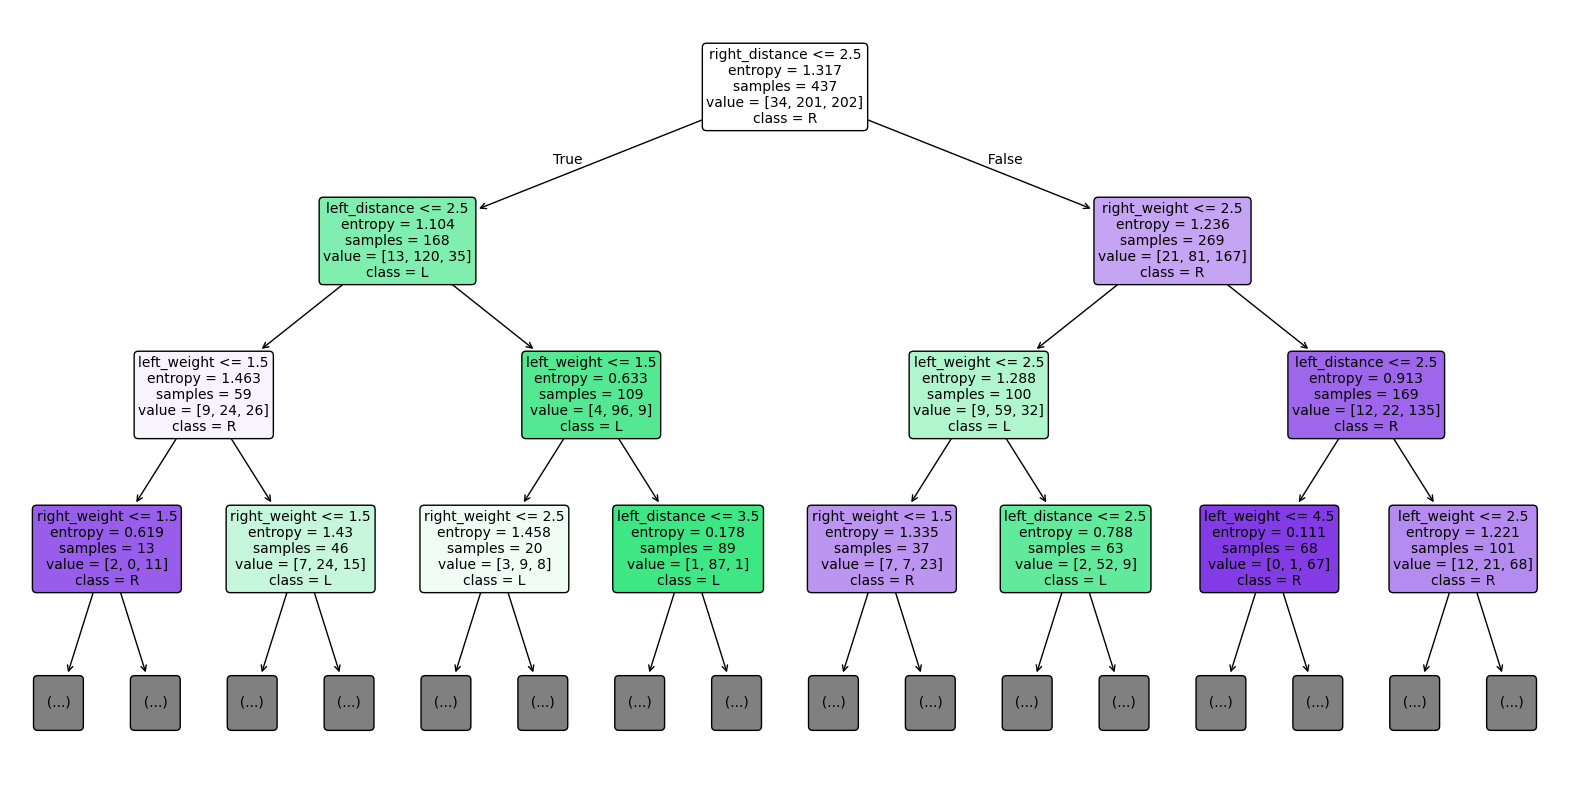

In [140]:
plt.figure(figsize=(20,10))
plot_tree(
    clf_entropy,
    feature_names=X.columns,
    class_names=clf_entropy.classes_,
    max_depth = 3,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()


10. Check if the observation defined as X_new  [4, 4, 3, 3] is classified as left

In [141]:
X_new = np.array([[4, 4, 3, 3]])

In [142]:
prediction = clf_entropy.predict(X_new)
prediction


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['L'], dtype=object)

In [143]:
is_left = (prediction[0] == 'L')
is_left


True

11. Use the gini classifier to make predictions on the test set

In [144]:
y_pred_gini = clf_gini.predict(X_test)
y_pred_gini

array(['R', 'L', 'B', 'R', 'L', 'R', 'R', 'R', 'B', 'L', 'R', 'R', 'B',
       'B', 'R', 'L', 'L', 'L', 'L', 'R', 'R', 'R', 'L', 'R', 'R', 'B',
       'R', 'B', 'L', 'R', 'R', 'L', 'R', 'L', 'R', 'R', 'B', 'R', 'R',
       'R', 'R', 'B', 'L', 'L', 'L', 'B', 'R', 'R', 'R', 'L', 'B', 'L',
       'L', 'L', 'R', 'L', 'R', 'R', 'R', 'R', 'L', 'L', 'R', 'L', 'R',
       'L', 'B', 'L', 'L', 'B', 'L', 'L', 'L', 'R', 'L', 'L', 'R', 'L',
       'R', 'L', 'L', 'L', 'R', 'R', 'L', 'L', 'L', 'R', 'L', 'L', 'L',
       'L', 'L', 'R', 'L', 'R', 'L', 'L', 'R', 'L', 'R', 'L', 'L', 'L',
       'L', 'L', 'L', 'R', 'B', 'L', 'R', 'L', 'R', 'L', 'L', 'B', 'R',
       'B', 'L', 'R', 'L', 'L', 'L', 'R', 'L', 'L', 'B', 'B', 'L', 'B',
       'R', 'L', 'R', 'R', 'B', 'R', 'L', 'R', 'L', 'L', 'L', 'L', 'R',
       'L', 'L', 'L', 'R', 'R', 'B', 'L', 'R', 'R', 'B', 'L', 'L', 'R',
       'R', 'R', 'R', 'R', 'B', 'L', 'L', 'R', 'L', 'R', 'L', 'L', 'B',
       'L', 'R', 'B', 'L', 'L', 'B', 'L', 'R', 'R', 'L', 'B', 'R

In [145]:
# from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()
# y_encoded = le.fit_transform(df['balance'])


12. Use the entropy classifier on the test set to make predictions

In [146]:
y_pred_entropy = clf_entropy.predict(X_test)
y_pred_entropy


array(['R', 'L', 'R', 'R', 'L', 'R', 'R', 'R', 'B', 'L', 'R', 'R', 'B',
       'B', 'R', 'L', 'L', 'L', 'L', 'R', 'R', 'R', 'L', 'R', 'R', 'B',
       'R', 'B', 'L', 'R', 'R', 'L', 'R', 'L', 'R', 'R', 'B', 'R', 'R',
       'R', 'L', 'B', 'R', 'L', 'R', 'B', 'R', 'R', 'R', 'L', 'B', 'L',
       'L', 'L', 'R', 'L', 'R', 'B', 'L', 'R', 'L', 'L', 'R', 'L', 'R',
       'L', 'B', 'L', 'L', 'B', 'B', 'L', 'L', 'R', 'L', 'L', 'R', 'L',
       'R', 'L', 'L', 'L', 'R', 'R', 'L', 'R', 'L', 'R', 'B', 'L', 'L',
       'L', 'L', 'R', 'L', 'R', 'L', 'L', 'R', 'L', 'R', 'L', 'L', 'L',
       'L', 'L', 'L', 'R', 'B', 'L', 'R', 'L', 'R', 'L', 'B', 'R', 'R',
       'B', 'L', 'R', 'L', 'L', 'R', 'R', 'L', 'R', 'B', 'R', 'L', 'B',
       'R', 'L', 'R', 'R', 'B', 'R', 'L', 'R', 'L', 'L', 'L', 'L', 'R',
       'L', 'L', 'L', 'B', 'R', 'B', 'L', 'R', 'R', 'B', 'L', 'L', 'R',
       'R', 'R', 'R', 'R', 'R', 'L', 'L', 'R', 'L', 'R', 'L', 'B', 'B',
       'L', 'R', 'L', 'L', 'L', 'B', 'L', 'R', 'B', 'L', 'B', 'R

13. Compare each prediction made with the gini and entropy classifier, what proportion of predictions are identical?

You can either compare each prediction using a for loop over all observations' indices, otherwise you simply loop over the two prediction vectors using the ```zip``` function
You can figure out what ```zip``` does by running
```
A=[1,2,3]
B=["a","b","c"]

for a, b in zip(A,B):
  print(a,b)
```

The numbers appearing in the solution will not necessarily the ones you will obtain depending on random operations you ran on your data.

In [147]:
same = 0
total = len(y_pred_gini) # ou len(y_pred_entropy) peu importe

for g, e in zip(y_pred_gini, y_pred_entropy):
    if g == e: # true
        same += 1 # 1ère itération si true = on ajoute 1

proportion_identical = same / total
same, total, proportion_identical


(169, 188, 0.898936170212766)

In [148]:
proportion_identical_2 = (y_pred_gini == y_pred_entropy).mean()
proportion_identical_2


np.float64(0.898936170212766)

14. What's the accuracy of the gini classifier?

Rappel
: accuracy = tx de bonne classification

à n'utiliser que pour les modèles de classification, jamais pour de la régression (R², RMSE, MAE) et inversement!

In [149]:
accuracy_gini = accuracy_score(y_test, y_pred_gini)
print(f"Accuracy (Gini classifier): {accuracy_gini:.4f}")



Accuracy (Gini classifier): 0.7447


valeurs différentes de jedha parce que stratify non précisé dans le train_test_split

15. What's the accuracy of the entropy classifier?

In [150]:
accuracy_entropy = accuracy_score(y_test, y_pred_entropy)
print(f"Accuracy ( entropy classifier): {accuracy_entropy:.4f}")

Accuracy ( entropy classifier): 0.7553


16. Display the "entropy" model's confusion matrix, what do you notice?

In [151]:
cm_entropy = confusion_matrix(y_test, y_pred_entropy)
#
cm_entropy


array([[ 2,  6,  7],
       [14, 72,  1],
       [15,  3, 68]])

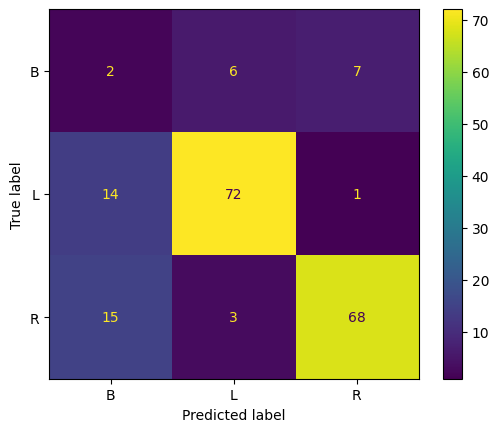

In [152]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(clf_entropy, X_test, y_test)

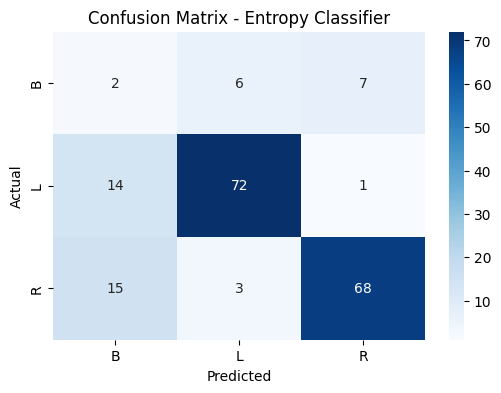

In [153]:

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_entropy,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=clf_entropy.classes_,
    yticklabels=clf_entropy.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Entropy Classifier")
plt.show()


Les cas "Balanced" sont rares → très peu d’exemples d’entraînement

l’entropie a du mal à reconnaître le moment parfait (égalité)

In [154]:
cm_gini = confusion_matrix(y_test, y_pred_gini)
#
cm_gini

array([[ 2,  6,  7],
       [14, 73,  0],
       [13,  8, 65]])

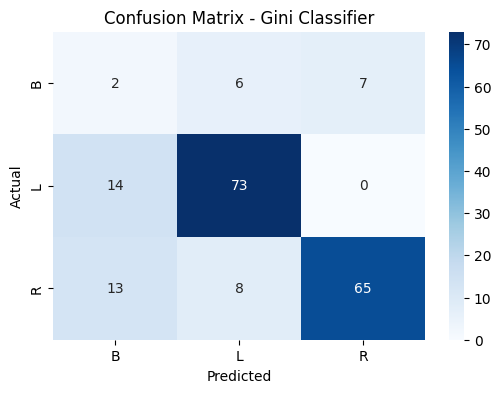

In [155]:

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_gini,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=clf_gini.classes_,
    yticklabels=clf_gini.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Gini Classifier")
plt.show()

**--> Most errors correspond to examples of class 'B' that are misclassified as 'R' or 'L'**

17. Display the classification report for both models on both training and testing data. Do the models perform well? Do they overfit ?

*Hint : have a look at scikit-learn's documentation about available metric functions* 😉

Gini

classification_report() renvoie 3 métriques


| Métrique      | Question à laquelle elle répond                                     |
| ------------- | ------------------------------------------------------------------- |
| **Precision** | Parmi ce que j’ai prédit comme positifs, combien étaient corrects ? |
| **Recall**    | Parmi tous les vrais positifs, combien ai-je retrouvé ?             |
| **F1-score**  | Est-ce que précision et rappel sont tous les deux bons ?            |


Rappel :

Precision=Vrais Positifs
/(Vrais Positifs + Faux Positifs)


Parmi toutes les prédictions POSITIVES du modèle, combien étaient correctes ?	​

Interprétation

→ Si je prédis “L”, à quel point ai-je raison ?

Une faible précision signifie :
→ le modèle prédit trop souvent “L” à tort (beaucoup de faux positifs).

Recall/sensibilité :
Parmi tous les vrais exemples POSITIFS, combien le modèle a-t-il retrouvés ?

Recall
=
Vrais Positifs /
(Vrais Positifs + Faux N
egatifs)
	​

Interprétation

→ Le modèle retrouve-t-il bien tous les L existants ?

Une faible recall signifie :
→ beaucoup de vrais “L” ont été manqués (faux négatifs).

macro_avg = moyenne des métriques en donnant le même poids à chaque classe, quelle que soit sa taille

Macro Precision= (Precision
B + Precision L + Precision R) /3
	​

	​


weighted average = moyenne pondérée selon le nombre d’observations par classe

	​

	​


In [156]:
y_train_pred_gini = clf_gini.predict(X_train)
print("Gini - TRAIN classification report:")
print(classification_report(y_train, y_train_pred_gini))


Gini - TRAIN classification report:
              precision    recall  f1-score   support

           B       1.00      1.00      1.00        34
           L       1.00      1.00      1.00       201
           R       1.00      1.00      1.00       202

    accuracy                           1.00       437
   macro avg       1.00      1.00      1.00       437
weighted avg       1.00      1.00      1.00       437



In [157]:
y_test_pred_gini = clf_gini.predict(X_test)
print("Gini - TEST classification report:")
print(classification_report(y_test, y_test_pred_gini))


Gini - TEST classification report:
              precision    recall  f1-score   support

           B       0.07      0.13      0.09        15
           L       0.84      0.84      0.84        87
           R       0.90      0.76      0.82        86

    accuracy                           0.74       188
   macro avg       0.60      0.58      0.58       188
weighted avg       0.81      0.74      0.77       188



Entropie

In [158]:
y_train_pred_entropy = clf_entropy.predict(X_train)
print("Entropy - TRAIN classification report:")
print(classification_report(y_train, y_train_pred_entropy))


Entropy - TRAIN classification report:
              precision    recall  f1-score   support

           B       1.00      1.00      1.00        34
           L       1.00      1.00      1.00       201
           R       1.00      1.00      1.00       202

    accuracy                           1.00       437
   macro avg       1.00      1.00      1.00       437
weighted avg       1.00      1.00      1.00       437



In [159]:
y_test_pred_entropy = clf_entropy.predict(X_test)
print("Entropy - TEST classification report:")
print(classification_report(y_test, y_test_pred_entropy))


Entropy - TEST classification report:
              precision    recall  f1-score   support

           B       0.06      0.13      0.09        15
           L       0.89      0.83      0.86        87
           R       0.89      0.79      0.84        86

    accuracy                           0.76       188
   macro avg       0.62      0.58      0.59       188
weighted avg       0.83      0.76      0.79       188



Output Jedha ci-dessous

## Fighting overfitting

18. How would you fight overfitting while still using decision tree classifiers? Try to find the set of hyper parameters that maximize the performances of the model on the test set. Did the model perform better ? Are there still ways to improve the model?

arbre plus simple → meilleure généralisation → moins d'overfitting
- limiter max_depth (la profondeur de l'arbre)
- minimiser min_samples_split (nbre min d'obs pour autoriser une séparation)

In [160]:
param_grid = {
    "max_depth": np.arange(1, 10),
    "min_samples_split": [2, 5, 10, 20],
    "criterion": ["gini"]  # ici on optimise Gini seulement
}

grid = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid,
    cv=10,
    scoring="accuracy"
)

grid.fit(X_train, y_train)


GridSearchCV(cv=10, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini'],
                         'max_depth': array([1, 2, 3, 4, 5, 6, 7, 8, 9]),
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='accuracy')

In [161]:
grid.best_params_


{'criterion': 'gini', 'max_depth': np.int64(4), 'min_samples_split': 5}

In [162]:
np.int64(4)

np.int64(4)

In [163]:
best_clf = grid.best_estimator_
best_clf

DecisionTreeClassifier(max_depth=np.int64(4), min_samples_split=5)

In [164]:
y_train_pred = best_clf.predict(X_train)
print("Classification report on train set:")
print(classification_report(y_train, y_train_pred))


Classification report on train set:
              precision    recall  f1-score   support

           B       0.67      0.06      0.11        34
           L       0.87      0.89      0.88       201
           R       0.82      0.93      0.87       202

    accuracy                           0.84       437
   macro avg       0.79      0.63      0.62       437
weighted avg       0.83      0.84      0.82       437



In [165]:
y_test_pred = best_clf.predict(X_test)
print("Classification report on test set:")
print(classification_report(y_test, y_test_pred))


Classification report on test set:
              precision    recall  f1-score   support

           B       0.20      0.07      0.10        15
           L       0.80      0.83      0.81        87
           R       0.77      0.84      0.80        86

    accuracy                           0.77       188
   macro avg       0.59      0.58      0.57       188
weighted avg       0.74      0.77      0.75       188



In [166]:
# report = classification_report(y_test, y_test_pred, output_dict=True)
# df_report = pd.DataFrame(report).transpose()
# df_report

## Feature engineering

19. Try and create new variables in order to improve the model's performance. Make again the preprocessings. And train a new model with gini criterion.

Rappel :
moment= weight×distance

In [181]:
df['left_prod'] = df['left_weight'] * df['left_distance']
df['right_prod'] = df['right_weight'] * df['right_distance']
df['balanced'] = df['right_prod'] - df['left_prod']
# avec balanced :
# le modèle capture la logique physique EXACTE du dataset
# et n’a plus besoin d’essayer de deviner des interactions complexes


In [182]:
X = df[['left_weight', 'left_distance', 'right_weight', 'right_distance',
        'left_prod', 'right_prod', 'balanced']]
y = df['balance']


In [183]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [184]:
clf_gini_new = DecisionTreeClassifier(criterion="gini")
clf_gini_new.fit(X_train, y_train)


DecisionTreeClassifier()

In [185]:
y_train_pred_new = clf_gini_new.predict(X_train)
print("Classification report on train set:")
print(classification_report(y_train, y_train_pred_new))

Classification report on train set:
              precision    recall  f1-score   support

           B       1.00      1.00      1.00        34
           L       1.00      1.00      1.00       201
           R       1.00      1.00      1.00       202

    accuracy                           1.00       437
   macro avg       1.00      1.00      1.00       437
weighted avg       1.00      1.00      1.00       437



In [186]:
y_pred_new = clf_gini_new.predict(X_test)
print(classification_report(y_test, y_pred_new))


              precision    recall  f1-score   support

           B       1.00      1.00      1.00        15
           L       1.00      1.00      1.00        87
           R       1.00      1.00      1.00        86

    accuracy                           1.00       188
   macro avg       1.00      1.00      1.00       188
weighted avg       1.00      1.00      1.00       188



In [187]:
df.head()

,balance,left_weight,left_distance,right_weight,right_distance,left_prod,right_prod,balanced
0,B,1,1,1,1,1,1,0
1,R,1,1,1,2,1,2,1
2,R,1,1,1,3,1,3,2
3,R,1,1,1,4,1,4,3
4,R,1,1,1,5,1,5,4
